In [1]:
import numpy as np
np.complex = complex
import babysmurf as bs


import matplotlib.pyplot as plt
from scipy import signal
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *
from source.include.demod import *

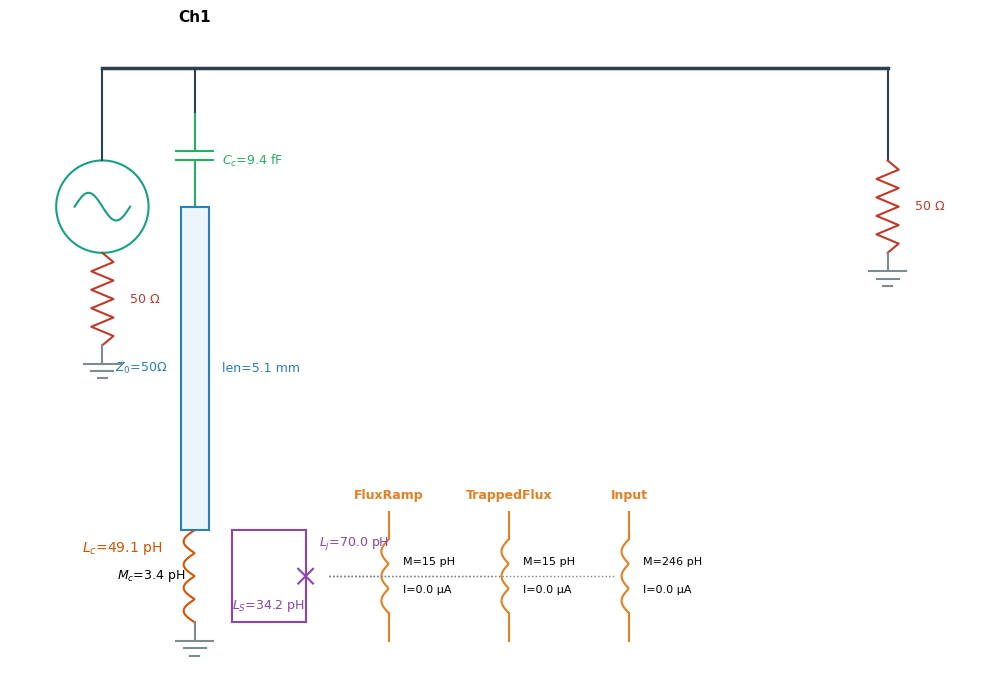

(200, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


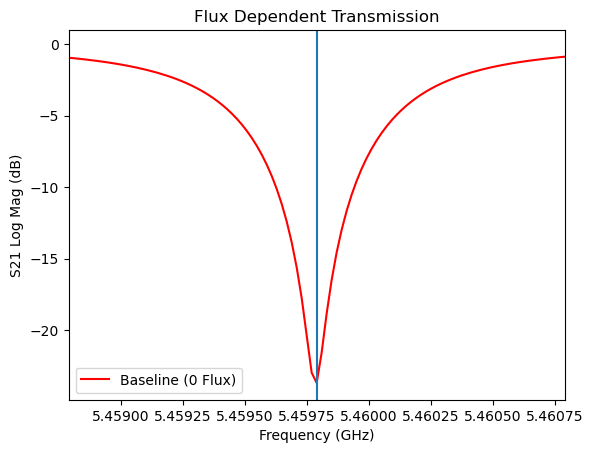

In [2]:
#Setting up uMux 
VNA = VNA_Simulator(z0=50)
squid_ch = SQUID(L_j=70e-12, L_s=34.2e-12, lamb=None, phi_ext=0.0) 
squid_ch.add_flux_line("FluxRamp", M=15e-12, initial_current=0.0)
squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
squid_ch.add_flux_line("Input", M=246e-12)   

ind_ch = Inductor(49.1e-12)
tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
length =5.1e-3 
Cc_val = 9.4e-15 
Qi_val = 85e3

cap_ch = Capacitor(C=Cc_val)
phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

channel = Channel(name=f"Ch{1}") 
channel.add(cap_ch)
channel.add(phys_res)

VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=1)

freqs = np.linspace((5.46-0.002)*1e9,(5.46+0.002)*1e9,200)
S = VNA.get_s_matrix(freqs)
S21 = S[1,0,:]
S21_mag = np.abs(S21)
S21_phase = np.atan(np.imag(S21)/np.real(S21))



plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', label = "Baseline (0 Flux)")
f_center = freqs[np.argmin(20*np.log10(S[1,0]))]

baseline = freqs[np.argmin(20*np.log10(S[1,0]))]

plt.axvline(baseline*1e-9)

plt.xlim((f_center-1e6)*1e-9,(f_center+1e6)*1e-9)
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.title("Flux Dependent Transmission")
plt.legend()








Text(0.5, 0, 'Time (us)')

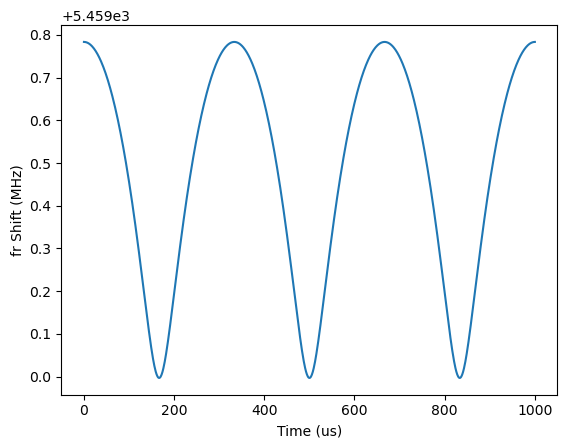

In [3]:
#Generate Flux Response to Ramp


times = np.linspace(0, 1e-3, 1000)
flux_ramp = Flux_Ramp(nPhi0=1, freq=3e3, time_array=times)
flux_array = flux_ramp.phi_ramp
squid_ch.flux_lines["FluxRamp"].set_flux(flux_array)
fr_array = channel.get_resonance(f_guess=baseline)

plt.plot(times*1e6, fr_array*1e-6)
plt.ylabel("fr Shift (MHz)")
plt.xlabel("Time (us)")


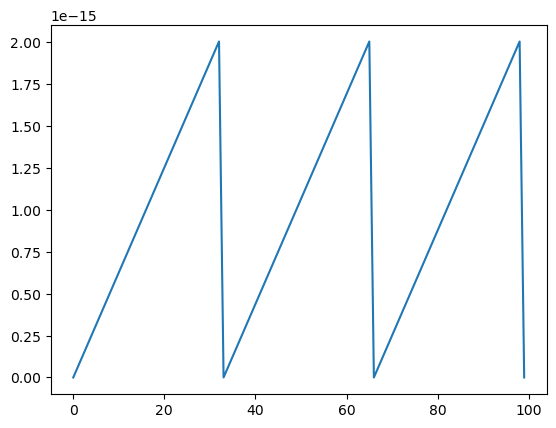

(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200, 2, 2)
(200

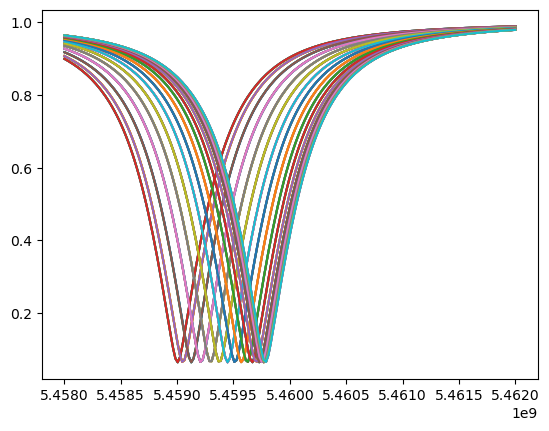

[np.float64(5459788944.7236185), np.float64(5459788944.7236185), np.float64(5459768844.221106), np.float64(5459748743.718593), np.float64(5459728643.216081), np.float64(5459708542.713568), np.float64(5459668341.708543), np.float64(5459628140.703518), np.float64(5459567839.19598), np.float64(5459507537.688442), np.float64(5459447236.180904), np.float64(5459366834.170855), np.float64(5459306532.663317), np.float64(5459206030.150754), np.float64(5459125628.140703), np.float64(5459045226.130653), np.float64(5459005025.125628), np.float64(5459005025.125628), np.float64(5459045226.130653), np.float64(5459125628.140703), np.float64(5459206030.150754), np.float64(5459286432.160804), np.float64(5459366834.170855), np.float64(5459447236.180904), np.float64(5459507537.688442), np.float64(5459567839.19598), np.float64(5459628140.703518), np.float64(5459668341.708543), np.float64(5459708542.713568), np.float64(5459728643.216081), np.float64(5459748743.718593), np.float64(5459768844.221106), np.floa

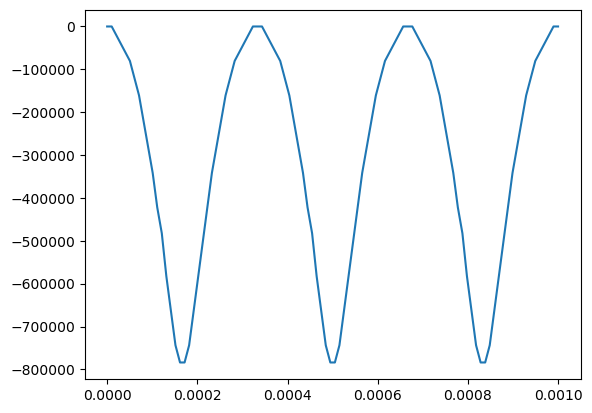

In [4]:
times = np.linspace(0, 1e-3,100)
flux_ramp = Flux_Ramp(nPhi0=1, freq=3e3, time_array=times)
flux_array = flux_ramp.phi_ramp
plt.plot(flux_array)
plt.show()

mag = []
phase = []
frs = []

for i in range(len(times)):
    t = times[i]
    flux = flux_array[i]
    squid_ch.flux_lines["FluxRamp"].set_flux(flux)
    S = VNA.get_s_matrix(freqs)
    S21 = S[1,0,:]
    S21_mag = np.abs(S21)
    plt.plot(freqs, S21_mag)
    S21_phase = np.atan(np.imag(S21)/np.real(S21))
    mag.append(S21_mag)
    phase.append(S21_phase)
    fr = freqs[np.argmin(S21_mag)]
    frs.append(fr)
plt.show()
    
    
print(frs)

plt.plot(times, frs-baseline)

    
    
    
    

In [5]:
offset = 5.e3 
mag = np.array(mag)
phase = np.array(phase)
freqs = np.array(freqs)
eta = bs.estimate_eta(freqs,mag,phase,offset=offset)
d,p,y,e,a = bs.lms_fit_demod_track(mag,phase,freqs,eta,reset_rate=4.e3) # this is annoyingly slow so only do a quarter


TypeError: only length-1 arrays can be converted to Python scalars